<a href="https://colab.research.google.com/github/parekhakhil/pyImageSearch/blob/main/208_canny_edge_detector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# OpenCV Edge Detection ( cv2.Canny )



This notebook is associated with the [OpenCV Edge Detection ( cv2.Canny )](https://www.pyimagesearch.com/2021/05/12/opencv-edge-detection-cv2-canny) blog post published on 2021-05-12.

Only the code for the blog post is here. Most codeblocks have a 1:1 relationship with what you find in the blog post with two exceptions: (1) Python classes are not separate files as they are typically organized with PyImageSearch projects, and (2) Command Line Argument parsing is replaced with an `args` dictionary that you can manipulate as needed.

We recommend that you execute (press ▶️) the code block-by-block, as-is, before adjusting parameters and `args` inputs. Once you've verified that the code is working, you are welcome to hack with it and learn from manipulating inputs, settings, and parameters. For more information on using Jupyter and Colab, please refer to these resources:

*   [Jupyter Notebook User Interface](https://jupyter-notebook.readthedocs.io/en/stable/notebook.html#notebook-user-interface)
*   [Overview of Google Colaboratory Features](https://colab.research.google.com/notebooks/basic_features_overview.ipynb)



Happy hacking!


<hr>



### Import Packages

In [8]:
# import the necessary packages
import matplotlib.pyplot as plt
import cv2
import numpy as np
import argparse
import glob

### Function to display images in Jupyter Notebooks and Google Colab

In [9]:
def plt_imshow(title, image):
	# convert the image frame BGR to RGB color space and display it
	image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
	plt.imshow(image)
	plt.title(title)
	plt.grid(False)
	plt.show()

### Implementing the Canny edge detector with OpenCV

In [10]:
# # construct the argument parser and parse the arguments
# ap = argparse.ArgumentParser()
# ap.add_argument("-i", "--image", type=str, required=True,
# 	help="path to input image")
# args = vars(ap.parse_args())

# since we are using Jupyter Notebooks we can replace our argument
# parsing code with *hard coded* arguments and values
args = {
    "image": "images/coins.png"
}

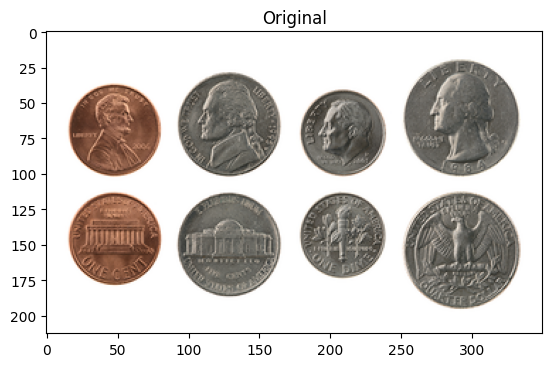

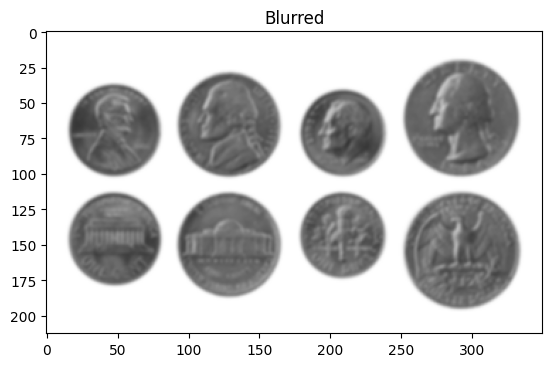

In [11]:
# load the image, convert it to grayscale, and blur it slightly
image = cv2.imread(args["image"])
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

# show the original and blurred images
plt_imshow("Original", image)
plt_imshow("Blurred", blurred)

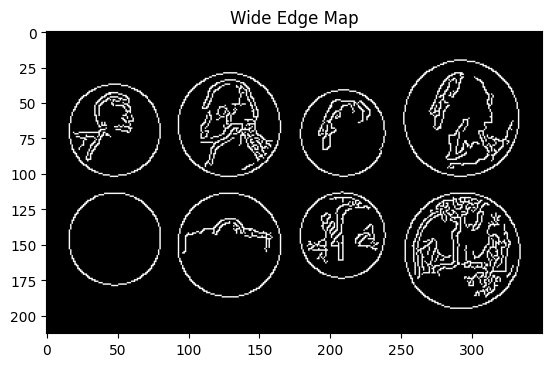

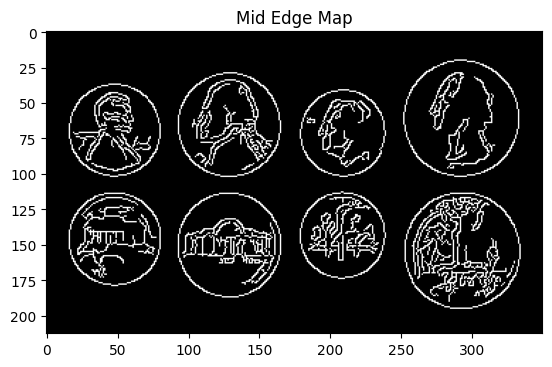

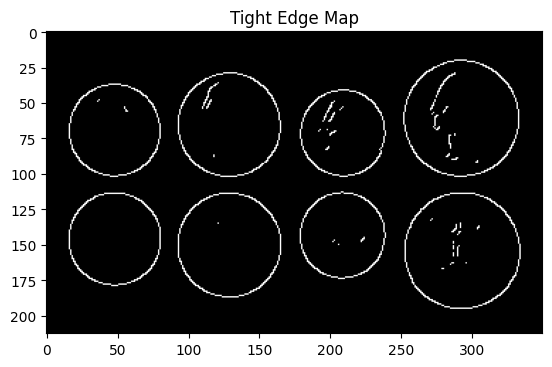

In [12]:
# compute a "wide", "mid-range", and "tight" threshold for the edges
# using the Canny edge detector
wide = cv2.Canny(blurred, 10, 200)
mid = cv2.Canny(blurred, 30, 150)
tight = cv2.Canny(blurred, 240, 250)

# show the output Canny edge maps
plt_imshow("Wide Edge Map", wide)
plt_imshow("Mid Edge Map", mid)
plt_imshow("Tight Edge Map", tight)

For a detailed walkthrough of the concepts and code, be sure to refer to the full tutorial, [OpenCV Edge Detection ( cv2.Canny )](https://www.pyimagesearch.com/2021/05/12/opencv-edge-detection-cv2-canny) published on 2021-05-12.

In [13]:
def auto_canny(image, sigma=0.33):
	# compute the median of the single channel pixel intensities
	v = np.median(image)

	# apply automatic Canny edge detection using the computed median
	lower = int(max(0, (1.0 - sigma) * v))
	upper = int(min(255, (1.0 + sigma) * v))
	edged = cv2.Canny(image, lower, upper)

	# return the edged image
	return edged

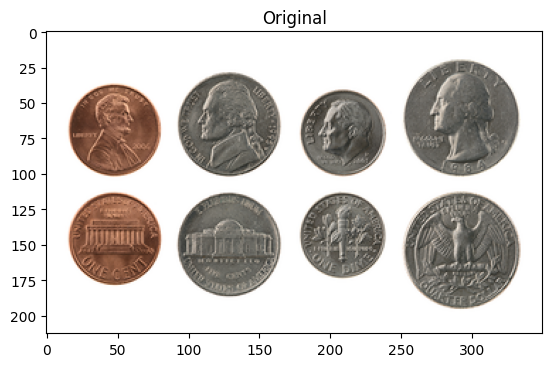

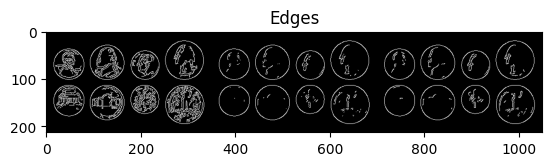

In [14]:
	image = cv2.imread(args["image"])
	gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
	blurred = cv2.GaussianBlur(gray, (3, 3), 0)

	# apply Canny edge detection using a wide threshold, tight
	# threshold, and automatically determined threshold
	wide = cv2.Canny(blurred, 10, 200)
	tight = cv2.Canny(blurred, 225, 250)
	auto = auto_canny(blurred)

	# show the images
	plt_imshow("Original", image)
	plt_imshow("Edges", np.hstack([wide, tight, auto]))

In [15]:
# import the necessary packages
import matplotlib.pyplot as plt
import numpy as np
import argparse
import cv2

In [16]:
def plt_imshow(title, image):
    # convert the image frame BGR to RGB color space and display it
	image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
	plt.imshow(image)
	plt.title(title)
	plt.grid(False)
	plt.show()

In [17]:

# # construct the argument parser and parse the arguments
# ap = argparse.ArgumentParser()
# ap.add_argument("-i", "--image", required=True,
# 	help="path to input image")
# ap.add_argument("-c", "--connectivity", type=int, default=4,
# 	help="connectivity for connected component analysis")
# args = vars(ap.parse_args())

# since we are using Jupyter Notebooks we can replace our argument
# parsing code with *hard coded* arguments and values
args = {
    "image": "./images/license_plate.png",
    "connectivity": 4
}

In [18]:
# load the input image from disk, convert it to grayscale, and
# threshold it
image = cv2.imread(args["image"])
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
thresh = cv2.threshold(gray, 0, 255,
	cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)[1]

In [19]:
# apply connected component analysis to the thresholded image
output = cv2.connectedComponentsWithStats(
	thresh, args["connectivity"], cv2.CV_32S)
(numLabels, labels, stats, centroids) = output

[INFO] examining component 1/17 (background)


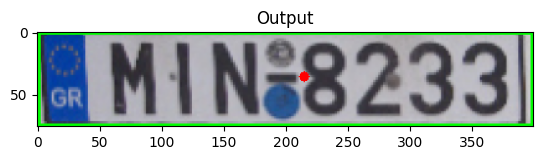

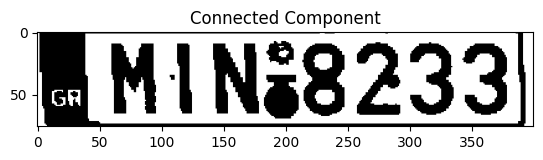

[INFO] examining component 2/17


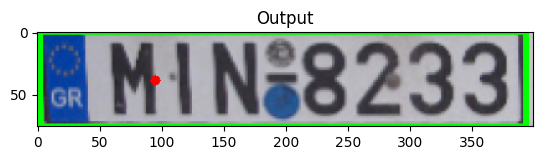

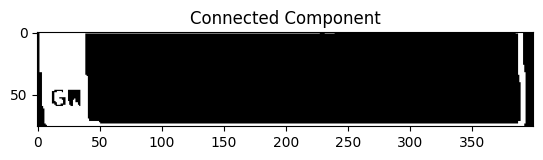

[INFO] examining component 3/17


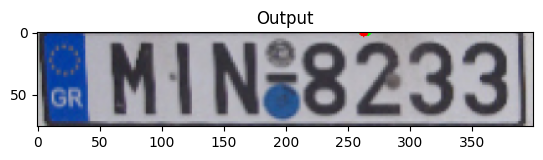

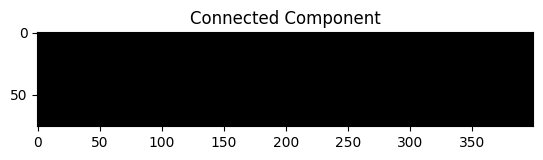

[INFO] examining component 4/17


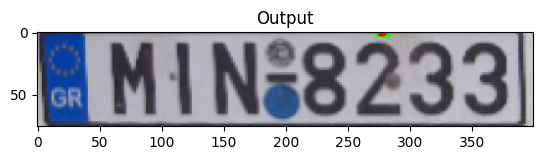

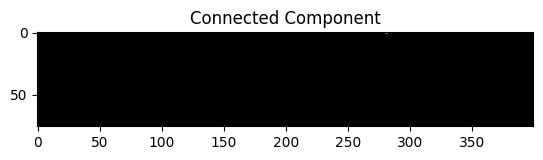

[INFO] examining component 5/17


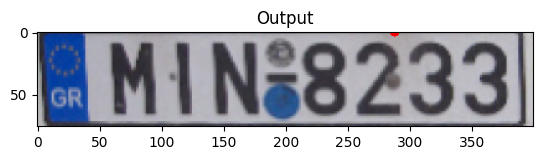

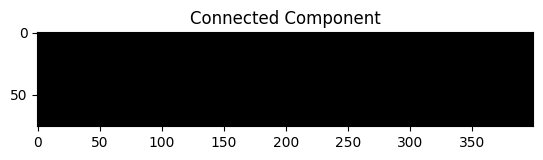

[INFO] examining component 6/17


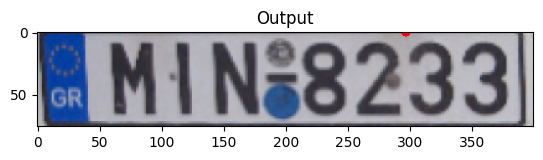

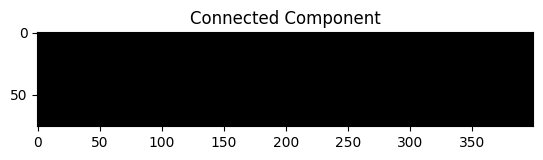

[INFO] examining component 7/17


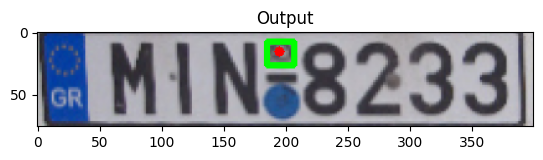

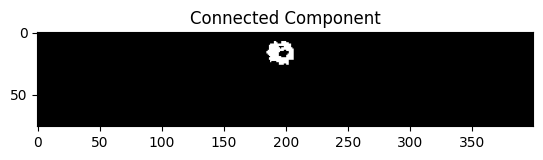

[INFO] examining component 8/17


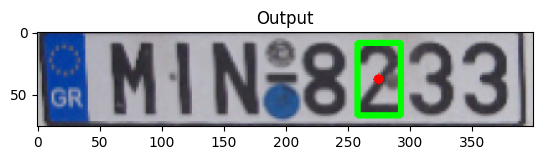

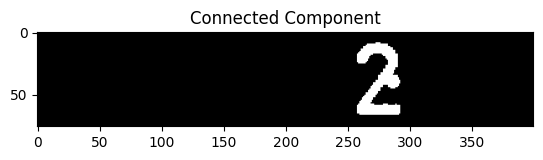

[INFO] examining component 9/17


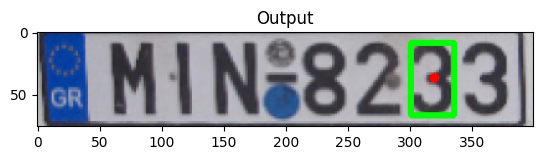

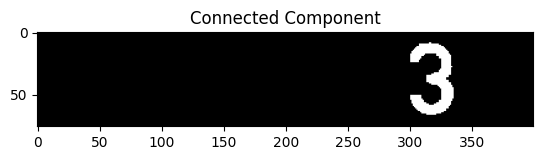

[INFO] examining component 10/17


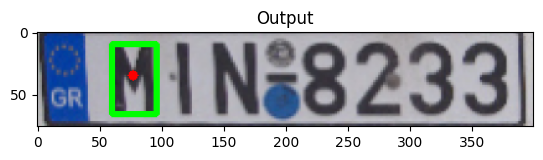

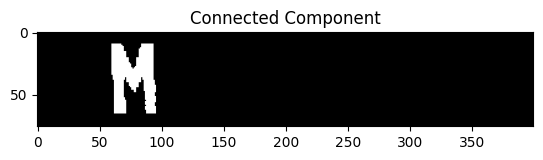

[INFO] examining component 11/17


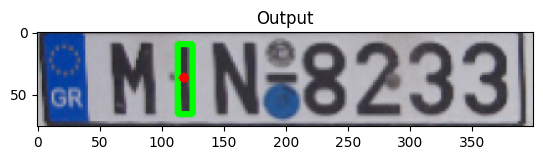

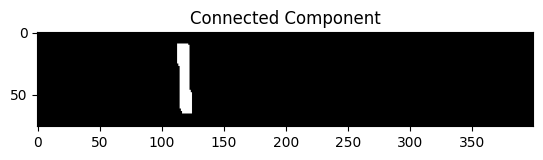

[INFO] examining component 12/17


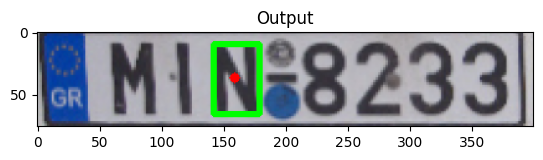

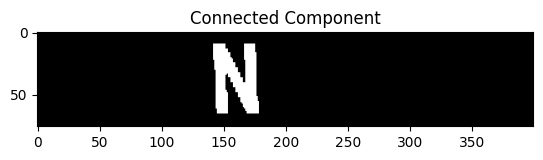

[INFO] examining component 13/17


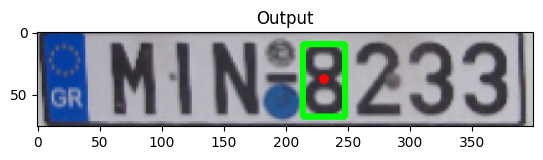

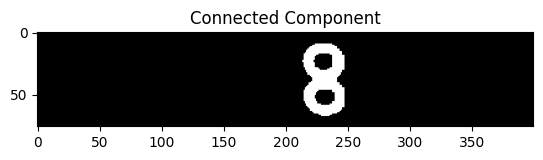

[INFO] examining component 14/17


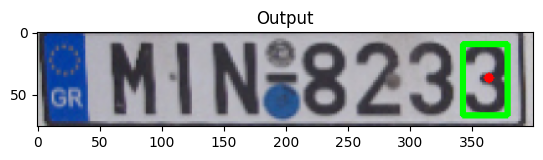

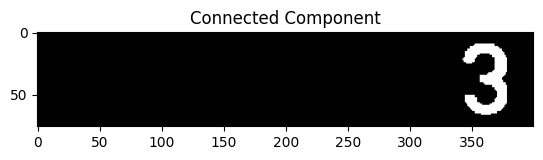

[INFO] examining component 15/17


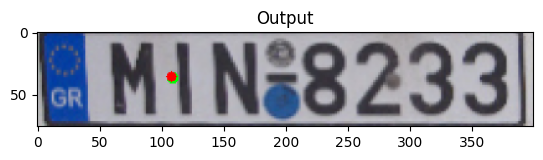

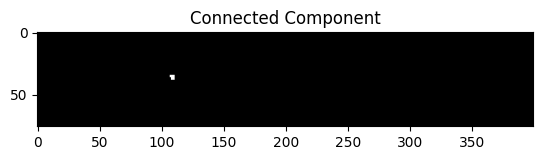

[INFO] examining component 16/17


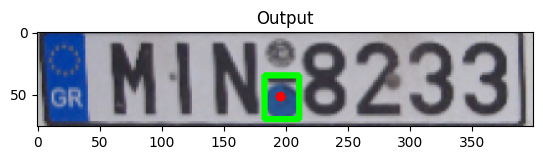

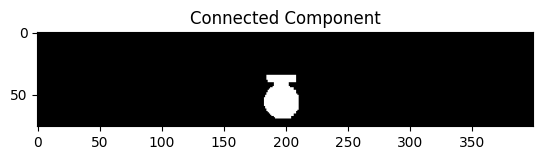

[INFO] examining component 17/17


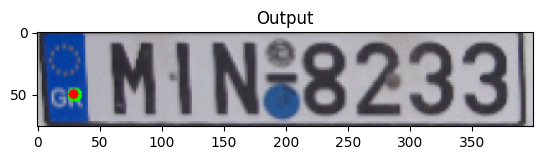

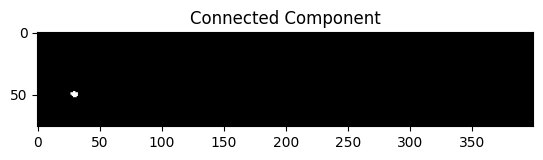

In [20]:
# loop over the number of unique connected component labels
for i in range(0, numLabels):
	# if this is the first component then we examining the
	# *background* (typically we would just ignore this
	# component in our loop)
	if i == 0:
		text = "examining component {}/{} (background)".format(
			i + 1, numLabels)

	# otherwise, we are examining an actual connected component
	else:
		text = "examining component {}/{}".format( i + 1, numLabels)

	# print a status message update for the current connected
	# component
	print("[INFO] {}".format(text))

	# extract the connected component statistics and centroid for
	# the current label
	x = stats[i, cv2.CC_STAT_LEFT]
	y = stats[i, cv2.CC_STAT_TOP]
	w = stats[i, cv2.CC_STAT_WIDTH]
	h = stats[i, cv2.CC_STAT_HEIGHT]
	area = stats[i, cv2.CC_STAT_AREA]
	(cX, cY) = centroids[i]

	# clone our original image (so we can draw on it) and then draw
	# a bounding box surrounding the connected component along with
	# a circle corresponding to the centroid
	output = image.copy()
	cv2.rectangle(output, (x, y), (x + w, y + h), (0, 255, 0), 3)
	cv2.circle(output, (int(cX), int(cY)), 4, (0, 0, 255), -1)

	# construct a mask for the current connected component by
	# finding a pixels in the labels array that have the current
	# connected component ID
	componentMask = (labels == i).astype("uint8") * 255

	# show our output image and connected component mask
	plt_imshow("Output", output)
	plt_imshow("Connected Component", componentMask)